In [ ]:
# Install all required dependencies
!pip install kaggle kagglehub xgboost scikit-learn pandas numpy matplotlib seaborn joblib tldextract --quiet

import os
import re
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tldextract

from collections import Counter
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)

print('All dependencies loaded successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.8 MB/s eta 0:00:00
All dependencies loaded successfully.


In [ ]:
from google.colab import files

print('Upload your kaggle.json file:')
uploaded = files.upload()

# Place kaggle.json in the expected location
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')

with open(kaggle_json_path, 'wb') as f:
    f.write(uploaded['kaggle.json'])

os.chmod(kaggle_json_path, 0o600)
print('kaggle.json configured successfully.')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
kaggle.json configured successfully.


In [ ]:
import kagglehub

# Download dataset via KaggleHub (no manual file uploads required)
dataset_path = kagglehub.dataset_download('sid321axn/malicious-urls-dataset')
print(f'Dataset downloaded to: {dataset_path}')

# List downloaded files
for root, dirs, files_list in os.walk(dataset_path):
    for file in files_list:
        full_path = os.path.join(root, file)
        size_mb = os.path.getsize(full_path) / (1024 * 1024)
        print(f'  {file}  ({size_mb:.1f} MB)')

100%|██████████| 16.9M/16.9M [00:00<00:00, 58.3MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/sid321axn/malicious-urls-dataset/versions/1
  malicious_phish.csv  (43.5 MB)


## Cell 4 — Load Dataset

In [ ]:
# Locate the CSV file dynamically
csv_file = None
for root, dirs, files_list in os.walk(dataset_path):
    for file in files_list:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)
            break

if csv_file is None:
    raise FileNotFoundError('CSV file not found in downloaded dataset.')

print(f'Loading: {csv_file}')
df = pd.read_csv(csv_file)

print(f'\nDataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nFirst 5 rows:')
df.head()

Loading: /root/.cache/kagglehub/datasets/sid321axn/malicious-urls-dataset/versions/1/malicious_phish.csv

Dataset shape: (651191, 2)

Columns: ['url', 'type']

First 5 rows:


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


## Cell 5 — Data Exploration

=== Dataset Overview ===
Total samples     : 651,191
Missing values    :
url     0
type    0
dtype: int64

=== Class Distribution ===
  benign          428,103  (65.7%)
  defacement       96,457  (14.8%)
  phishing         94,111  (14.5%)
  malware          32,520  (5.0%)


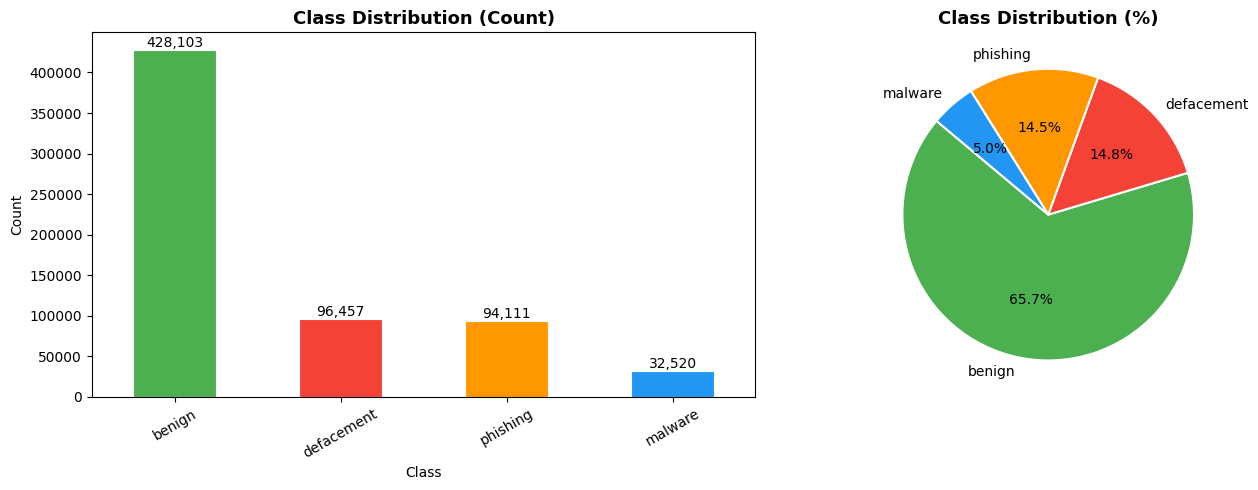

Plot saved.


In [ ]:
# Identify URL column and label column
# Dataset columns: 'url' and 'type'
URL_COL = 'url'
LABEL_COL = 'type'

print('=== Dataset Overview ===')
print(f'Total samples     : {len(df):,}')
print(f'Missing values    :')
print(df.isnull().sum())

print(f'\n=== Class Distribution ===')
class_dist = df[LABEL_COL].value_counts()
for cls, count in class_dist.items():
    pct = count / len(df) * 100
    print(f'  {cls:<15} {count:>7,}  ({pct:.1f}%)')

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4CAF50', '#F44336', '#FF9800', '#2196F3']

# Bar chart
class_dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(class_dist, labels=class_dist.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Cell 6 — Data Cleaning

In [ ]:
print(f'Before cleaning: {len(df):,} rows')

# Drop rows with missing URL or label
df.dropna(subset=[URL_COL, LABEL_COL], inplace=True)

# Drop duplicate URLs (keep first occurrence)
df.drop_duplicates(subset=[URL_COL], keep='first', inplace=True)

# Strip whitespace from URL strings
df[URL_COL] = df[URL_COL].astype(str).str.strip()

# Remove rows where URL is empty after stripping
df = df[df[URL_COL].str.len() > 0]

# Normalize label strings to lowercase
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()

# Reset index
df.reset_index(drop=True, inplace=True)

print(f'After cleaning  : {len(df):,} rows')
print(f'\nFinal class distribution:')
print(df[LABEL_COL].value_counts())

Before cleaning: 651,191 rows
After cleaning  : 641,119 rows

Final class distribution:
type
benign        428080
defacement     95308
phishing       94086
malware        23645
Name: count, dtype: int64


## Cell 7 — Feature Engineering

All features are extracted from the raw URL string only. No external lookups required.

In [ ]:
def calculate_entropy(string):
    """Shannon entropy of a string — high entropy indicates randomness."""
    if not string:
        return 0.0
    freq = Counter(string)
    length = len(string)
    return -sum((count / length) * math.log2(count / length) for count in freq.values())


def extract_features(url):
    """Extract 24 lexical features from a URL string."""
    features = {}

    # --- Basic length features ---
    features['url_length']          = len(url)
    features['url_entropy']         = round(calculate_entropy(url), 4)

    # --- Protocol ---
    features['has_https']           = int(url.startswith('https'))
    features['has_http']            = int(url.startswith('http://'))

    # --- Character counts ---
    features['num_dots']            = url.count('.')
    features['num_hyphens']         = url.count('-')
    features['num_underscores']     = url.count('_')
    features['num_slashes']         = url.count('/')
    features['num_question_marks']  = url.count('?')
    features['num_equals']          = url.count('=')
    features['num_ampersands']      = url.count('&')
    features['num_at_symbols']      = url.count('@')
    features['num_percent']         = url.count('%')
    features['num_digits']          = sum(c.isdigit() for c in url)
    features['digit_ratio']         = round(features['num_digits'] / max(len(url), 1), 4)

    # --- Suspicious patterns ---
    features['has_ip_address']      = int(bool(re.search(
        r'(\d{1,3}\.){3}\d{1,3}', url)))
    features['has_port']            = int(bool(re.search(r':\d{2,5}', url)))
    features['has_hex_encoding']    = int('%' in url)
    features['double_slash_in_path']= int('//' in url[8:])  # skip protocol
    features['has_shortening']      = int(bool(re.search(
        r'(bit\.ly|goo\.gl|tinyurl|t\.co|ow\.ly|is\.gd|buff\.ly|adf\.ly)',
        url, re.IGNORECASE)))

    # --- Domain features ---
    try:
        parsed   = urlparse(url if url.startswith('http') else 'http://' + url)
        ext      = tldextract.extract(url)
        domain   = ext.domain
        subdomain= ext.subdomain
        suffix   = ext.suffix
    except Exception:
        domain, subdomain, suffix = '', '', ''

    features['domain_length']       = len(domain)
    features['subdomain_count']     = len(subdomain.split('.')) if subdomain else 0
    features['domain_entropy']      = round(calculate_entropy(domain), 4)
    features['tld_length']          = len(suffix)

    return features


print('Extracting features from URLs...')
print('(This may take 2-4 minutes for 650k rows)')

features_list = [extract_features(url) for url in df[URL_COL]]
feature_df    = pd.DataFrame(features_list)

print(f'Feature matrix shape: {feature_df.shape}')
print(f'\nFeature columns:')
for col in feature_df.columns:
    print(f'  {col}')

print(f'\nFeature statistics:')
feature_df.describe().round(2)

Extracting features from URLs...
(This may take 2-4 minutes for 650k rows)
Feature matrix shape: (641119, 24)

Feature columns:
  url_length
  url_entropy
  has_https
  has_http
  num_dots
  num_hyphens
  num_underscores
  num_slashes
  num_question_marks
  num_equals
  num_ampersands
  num_at_symbols
  num_percent
  num_digits
  digit_ratio
  has_ip_address
  has_port
  has_hex_encoding
  double_slash_in_path
  has_shortening
  domain_length
  subdomain_count
  domain_entropy
  tld_length

Feature statistics:


,url_length,url_entropy,has_https,has_http,num_dots,num_hyphens,num_underscores,num_slashes,num_question_marks,num_equals,...,digit_ratio,has_ip_address,has_port,has_hex_encoding,double_slash_in_path,has_shortening,domain_length,subdomain_count,domain_entropy,tld_length
count,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00,...,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00,641119.00
mean,59.76,4.22,0.02,0.25,2.19,1.56,0.43,2.92,0.22,0.59,...,0.07,0.02,0.01,0.04,0.00,0.05,9.89,0.50,2.71,2.99
std,44.89,0.42,0.15,0.43,1.49,2.98,1.18,1.90,0.44,1.49,...,0.10,0.14,0.10,0.19,0.06,0.23,4.84,1.01,0.57,0.90
min,1.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00
25%,32.00,3.96,0.00,0.00,1.00,0.00,0.00,2.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,7.00,0.00,2.50,3.00
50%,47.00,4.23,0.00,0.00,2.00,0.00,0.00,3.00,0.00,0.00,...,0.03,0.00,0.00,0.00,0.00,0.00,9.00,0.00,2.75,3.00
75%,76.00,4.49,0.00,1.00,3.00,2.00,0.00,4.00,0.00,0.00,...,0.10,0.00,0.00,0.00,0.00,0.00,13.00,1.00,3.12,3.00
max,2175.00,7.50,1.00,1.00,42.00,87.00,79.00,41.00,20.00,51.00,...,0.80,1.00,1.00,1.00,1.00,1.00,151.00,33.00,6.72,18.00


## Cell 8 — Label Encoding and Train/Test Split

In [ ]:
# Encode labels: benign=0, defacement=1, malware=2, phishing=3
le = LabelEncoder()
y  = le.fit_transform(df[LABEL_COL])
X  = feature_df.values

print('Label encoding:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    count = (y == idx).sum()
    print(f'  {idx} -> {cls:<15} ({count:,} samples)')

# Save encoder for backend use
joblib.dump(le, 'label_encoder.pkl')
print('\nLabelEncoder saved to label_encoder.pkl')

# Stratified split to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'\nTrain set : {X_train.shape[0]:,} samples')
print(f'Test set  : {X_test.shape[0]:,} samples')

# Verify stratification
print(f'\nTrain class distribution:')
for cls_idx, cls_name in enumerate(le.classes_):
    count = (y_train == cls_idx).sum()
    pct   = count / len(y_train) * 100
    print(f'  {cls_name:<15} {count:>7,}  ({pct:.1f}%)')

Label encoding:
  0 -> benign          (428,080 samples)
  1 -> defacement      (95,308 samples)
  2 -> malware         (23,645 samples)
  3 -> phishing        (94,086 samples)

LabelEncoder saved to label_encoder.pkl

Train set : 512,895 samples
Test set  : 128,224 samples

Train class distribution:
  benign          342,464  (66.8%)
  defacement       76,246  (14.9%)
  malware          18,916  (3.7%)
  phishing         75,269  (14.7%)


## Cell 9 — Model 1: Random Forest (Baseline)

In [ ]:
print('Training Random Forest...')
print('(This may take 3-6 minutes on CPU, faster on GPU runtime)')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_model.fit(X_train, y_train)
print('Random Forest training complete.')

Training Random Forest...
(This may take 3-6 minutes on CPU, faster on GPU runtime)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   30.2s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  2.2min


Random Forest training complete.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.3min finished


## Cell 10 — Model 2: XGBoost

In [ ]:
print('Training XGBoost...')

# Compute class weights manually for XGBoost
class_counts   = np.bincount(y_train)
total_samples  = len(y_train)
n_classes      = len(class_counts)
sample_weights = np.array([total_samples / (n_classes * class_counts[i]) for i in y_train])

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    verbosity=1,
    device='cuda' if os.environ.get('COLAB_GPU') else 'cpu'
)

xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print('XGBoost training complete.')

Training XGBoost...
[0]	validation_0-mlogloss:1.24199
[50]	validation_0-mlogloss:0.23725
[100]	validation_0-mlogloss:0.19456
[150]	validation_0-mlogloss:0.17760
[200]	validation_0-mlogloss:0.16785
[250]	validation_0-mlogloss:0.16104
[299]	validation_0-mlogloss:0.15611
XGBoost training complete.


## Cell 11 — Evaluation: Random Forest

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    3.5s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    3.5s finished


========== Random Forest Results ==========
Accuracy  : 0.9563  (95.63%)
Precision : 0.9577
Recall    : 0.9563
F1 Score  : 0.9567

Per-class Classification Report:
              precision    recall  f1-score   support

      benign       0.98      0.97      0.97     85616
  defacement       0.96      0.99      0.98     19062
     malware       0.98      0.92      0.95      4729
    phishing       0.84      0.89      0.86     18817

    accuracy                           0.96    128224
   macro avg       0.94      0.94      0.94    128224
weighted avg       0.96      0.96      0.96    128224



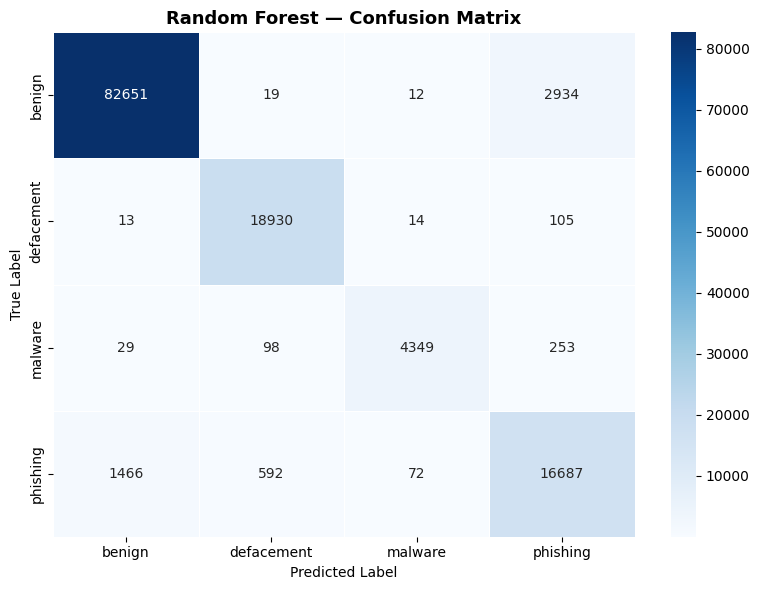

Confusion matrix saved to confusion_matrix_random_forest.png


In [ ]:
def evaluate_model(model, X_test, y_test, label_encoder, model_name):
    """Evaluate model and print full classification report with confusion matrix."""
    y_pred = model.predict(X_test)

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f'========== {model_name} Results ==========')
    print(f'Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
    print(f'Precision : {precision:.4f}')
    print(f'Recall    : {recall:.4f}')
    print(f'F1 Score  : {f1:.4f}')

    print(f'\nPer-class Classification Report:')
    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    fname = f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix saved to {fname}')

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'y_pred': y_pred}


rf_results = evaluate_model(rf_model, X_test, y_test, le, 'Random Forest')

## Cell 12 — Evaluation: XGBoost

========== XGBoost Results ==========
Accuracy  : 0.9430  (94.30%)
Precision : 0.9489
Recall    : 0.9430
F1 Score  : 0.9448

Per-class Classification Report:
              precision    recall  f1-score   support

      benign       0.99      0.94      0.96     85616
  defacement       0.97      0.99      0.98     19062
     malware       0.94      0.93      0.94      4729
    phishing       0.76      0.90      0.83     18817

    accuracy                           0.94    128224
   macro avg       0.92      0.94      0.93    128224
weighted avg       0.95      0.94      0.94    128224



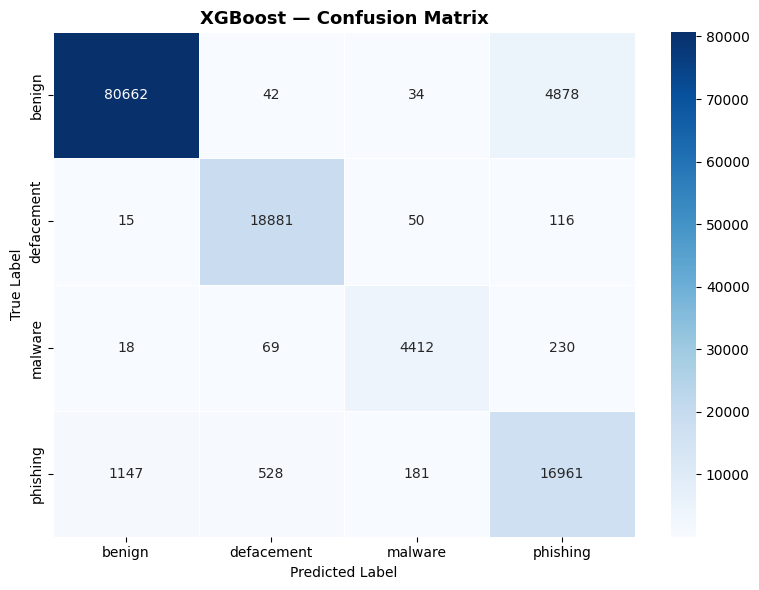

Confusion matrix saved to confusion_matrix_xgboost.png


In [ ]:
xgb_results = evaluate_model(xgb_model, X_test, y_test, le, 'XGBoost')

## Cell 13 — Model Comparison

=== Final Model Comparison ===
               Accuracy  Precision  Recall  F1 Score
Model                                               
Random Forest    0.9563     0.9577  0.9563    0.9567
XGBoost          0.9430     0.9489  0.9430    0.9448


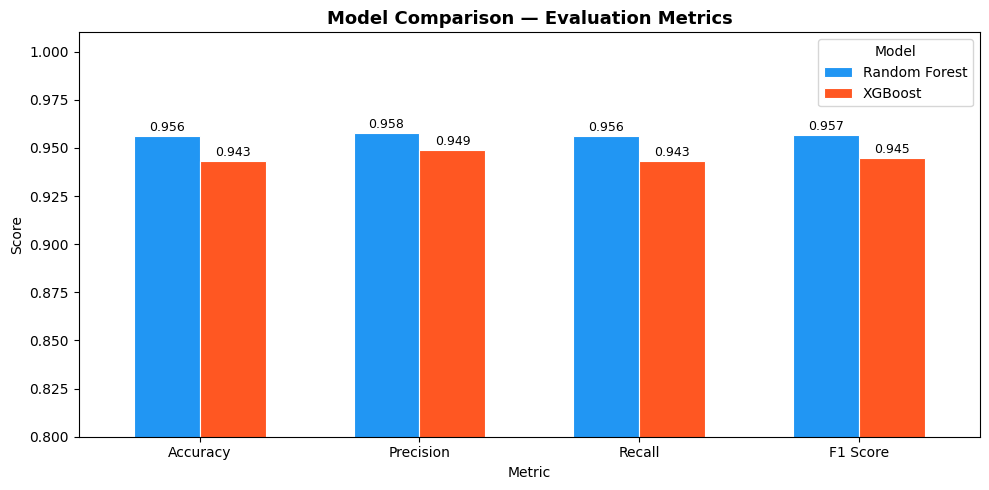


Best model selected: Random Forest


In [ ]:
comparison = pd.DataFrame({
    'Model'    : ['Random Forest', 'XGBoost'],
    'Accuracy' : [rf_results['accuracy'],  xgb_results['accuracy']],
    'Precision': [rf_results['precision'], xgb_results['precision']],
    'Recall'   : [rf_results['recall'],    xgb_results['recall']],
    'F1 Score' : [rf_results['f1'],        xgb_results['f1']]
})

comparison = comparison.set_index('Model').round(4)
print('=== Final Model Comparison ===')
print(comparison.to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
comparison.T.plot(kind='bar', ax=ax, color=['#2196F3', '#FF5722'],
                  edgecolor='white', linewidth=0.8, width=0.6)
ax.set_title('Model Comparison — Evaluation Metrics', fontsize=13, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_ylim(0.8, 1.01)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Model')
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Select best model automatically
best_model_name = comparison['F1 Score'].idxmax()
best_model      = rf_model if best_model_name == 'Random Forest' else xgb_model
print(f'\nBest model selected: {best_model_name}')

## Cell 14 — Feature Importance

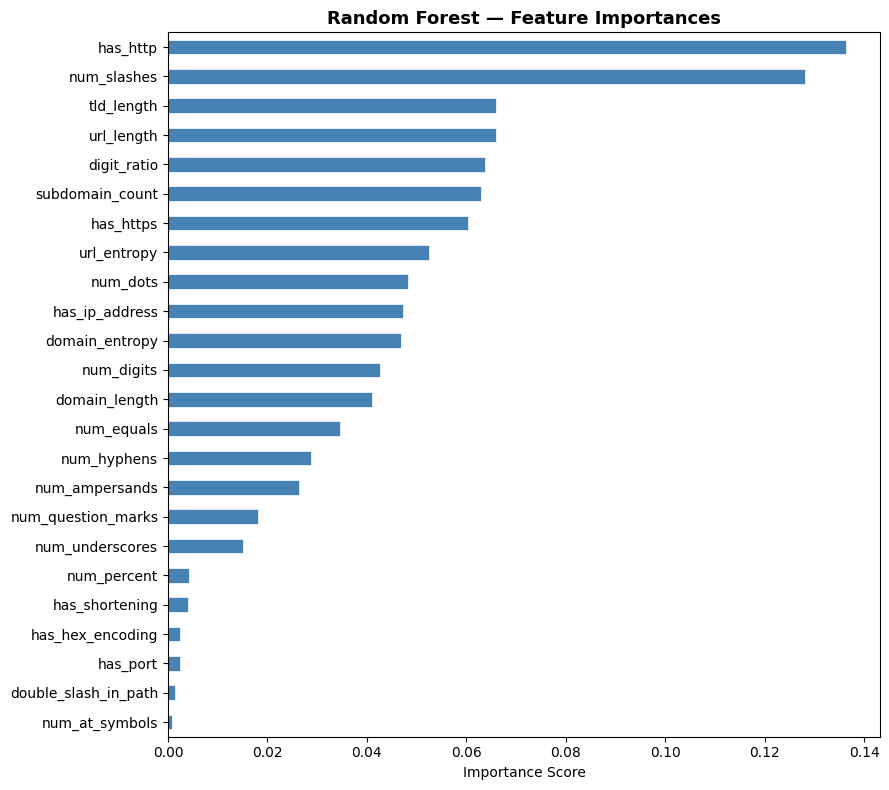

Top 10 most important features:
has_http           0.136339
num_slashes        0.128102
tld_length         0.065967
url_length         0.065879
digit_ratio        0.063657
subdomain_count    0.062928
has_https          0.060239
url_entropy        0.052518
num_dots           0.048208
has_ip_address     0.047225


In [ ]:
feature_names = list(feature_df.columns)

# Random Forest feature importances
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names)
rf_importances = rf_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
rf_importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
print(rf_importances.sort_values(ascending=False).head(10).to_string())

## Cell 15 — Save Models and Feature List

In [ ]:
import json

# Save both models
joblib.dump(rf_model,  'random_forest_model.pkl',  compress=3)
joblib.dump(xgb_model, 'xgboost_model.pkl',        compress=3)
joblib.dump(le,        'label_encoder.pkl')

# Save feature column names for consistent extraction at inference time
with open('feature_columns.json', 'w') as f:
    json.dump(feature_names, f)

# Save model metadata
metadata = {
    'dataset'      : 'sid321axn/malicious-urls-dataset',
    'classes'      : le.classes_.tolist(),
    'n_features'   : len(feature_names),
    'feature_names': feature_names,
    'best_model'   : best_model_name,
    'rf_accuracy'  : round(rf_results['accuracy'], 4),
    'xgb_accuracy' : round(xgb_results['accuracy'], 4),
    'rf_f1'        : round(rf_results['f1'], 4),
    'xgb_f1'       : round(xgb_results['f1'], 4)
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Files saved:')
saved_files = [
    'random_forest_model.pkl',
    'xgboost_model.pkl',
    'label_encoder.pkl',
    'feature_columns.json',
    'model_metadata.json'
]
for fname in saved_files:
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / (1024 * 1024)
        print(f'  {fname:<35} ({size_mb:.2f} MB)')

print(f'\nBest model for production: {best_model_name}')
print(f'Classes: {le.classes_.tolist()}')

Files saved:
  random_forest_model.pkl             (166.48 MB)
  xgboost_model.pkl                   (3.98 MB)
  label_encoder.pkl                   (0.00 MB)
  feature_columns.json                (0.00 MB)
  model_metadata.json                 (0.00 MB)

Best model for production: Random Forest
Classes: ['benign', 'defacement', 'malware', 'phishing']


## Cell 16 — Download Saved Files to Local Machine

In [ ]:
from google.colab import files

# Download all model artifacts
for fname in saved_files:
    if os.path.exists(fname):
        files.download(fname)
        print(f'Downloading: {fname}')

print('\nAll files downloaded. Place them in your Flask backend directory.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: random_forest_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: feature_columns.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: model_metadata.json

All files downloaded. Place them in your Flask backend directory.


## Cell 17 — Inference Test: Single URL

In [ ]:
def predict_url(url, model=None, label_encoder=None, feature_cols=None):
    """
    Predict whether a single URL is malicious and identify attack type.
    Returns dict: {'url', 'prediction', 'label', 'confidence', 'class_probabilities'}
    """
    if model is None:
        model         = best_model
    if label_encoder is None:
        label_encoder = le
    if feature_cols is None:
        feature_cols  = feature_names

    features     = extract_features(url)
    feature_vec  = np.array([[features[col] for col in feature_cols]])

    pred_idx     = model.predict(feature_vec)[0]
    pred_label   = label_encoder.inverse_transform([pred_idx])[0]
    proba        = model.predict_proba(feature_vec)[0]

    class_proba  = {
        label_encoder.classes_[i]: round(float(proba[i]), 4)
        for i in range(len(label_encoder.classes_))
    }

    return {
        'url'                : url,
        'prediction'         : 'malicious' if pred_label != 'benign' else 'genuine',
        'attack_type'        : pred_label if pred_label != 'benign' else None,
        'confidence'         : round(float(proba[pred_idx]), 4),
        'class_probabilities': class_proba
    }


# Test with sample URLs
test_urls = [
    'https://www.google.com',
    'http://192.168.1.1/malware/payload.exe',
    'http://paypa1.com/login?verify=user&pass=secure',
    'http://bit.ly/3xABcD'
]

print('=== Inference Tests ===')
for url in test_urls:
    result = predict_url(url)
    print(f'\nURL        : {result["url"]}')
    print(f'Prediction : {result["prediction"].upper()}')
    if result['attack_type']:
        print(f'Attack Type: {result["attack_type"]}')
    print(f'Confidence : {result["confidence"]:.2%}')
    print(f'Probabilities: {result["class_probabilities"]}')

=== Inference Tests ===

URL        : https://www.google.com
Prediction : MALICIOUS
Attack Type: phishing
Confidence : 95.05%
Probabilities: {'benign': 0.0301, 'defacement': 0.0, 'malware': 0.0194, 'phishing': 0.9505}

URL        : http://192.168.1.1/malware/payload.exe
Prediction : MALICIOUS
Attack Type: malware
Confidence : 97.80%
Probabilities: {'benign': 0.0, 'defacement': 0.0, 'malware': 0.978, 'phishing': 0.022}


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      |


URL        : http://paypa1.com/login?verify=user&pass=secure
Prediction : MALICIOUS
Attack Type: defacement
Confidence : 78.27%
Probabilities: {'benign': 0.0998, 'defacement': 0.7827, 'malware': 0.0033, 'phishing': 0.1142}

URL        : http://bit.ly/3xABcD
Prediction : MALICIOUS
Attack Type: phishing
Confidence : 95.63%
Probabilities: {'benign': 0.0246, 'defacement': 0.0087, 'malware': 0.0104, 'phishing': 0.9563}


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s f

## Cell 18 — Inference Test: Batch CSV

In [ ]:
def predict_csv(filepath, url_column='url', model=None, label_encoder=None, feature_cols=None):
    """
    Predict on a CSV file containing URLs.
    Returns a DataFrame with predictions appended.
    """
    if model is None:
        model         = best_model
    if label_encoder is None:
        label_encoder = le
    if feature_cols is None:
        feature_cols  = feature_names

    input_df = pd.read_csv(filepath)

    if url_column not in input_df.columns:
        raise ValueError(f'Column "{url_column}" not found. Available: {input_df.columns.tolist()}')

    results = [predict_url(str(url), model, label_encoder, feature_cols)
               for url in input_df[url_column]]

    result_df = pd.DataFrame(results)
    output_path = filepath.replace('.csv', '_predictions.csv')
    result_df.to_csv(output_path, index=False)
    print(f'Predictions saved to: {output_path}')
    return result_df


# Create a small test CSV and run batch prediction
sample_csv = pd.DataFrame({'url': test_urls})
sample_csv.to_csv('sample_urls.csv', index=False)

batch_results = predict_csv('sample_urls.csv')
print('\nBatch prediction results:')
print(batch_results[['url', 'prediction', 'attack_type', 'confidence']].to_string(index=False))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      |

Predictions saved to: sample_urls_predictions.csv

Batch prediction results:
                                            url prediction attack_type  confidence
                         https://www.google.com  malicious    phishing      0.9505
         http://192.168.1.1/malware/payload.exe  malicious     malware      0.9780
http://paypa1.com/login?verify=user&pass=secure  malicious  defacement      0.7827
                           http://bit.ly/3xABcD  malicious    phishing      0.9563


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
